In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import osmnx as ox
import pandas as pd
import matplotlib.lines as mlines
from tqdm import tqdm
from itertools import combinations
from pykml import parser
from jellyfish import jaro_similarity

from shapely.geometry import Point, LineString, Polygon

## Isofare Mapping: How far does your fare get you?

This project introduces the notion of "isofare" maps, inspired by isochrone maps, which show all points reachable from a given starting point within a certain period of time. Building on this concept, "isofare" maps show all points reachable from a given starting point for a certain cost. 

Which parts of the city are more cost-effectively connected by public transit? Given your starting location, how far does a $2.25 bus fare take you? When should you take a bikeshare over a bus?


In [2]:
CRS = 4326 #https://epsg.io/4326

In [3]:
WALK_SPEED_MPS = 1.4
WALK_MINUTES   = 10
WALK_RADIUS_M  = WALK_SPEED_MPS * WALK_MINUTES * 60

BIKE_SPEED_MPS = 4

In [4]:
BUDGET_LEVELS = [0.50, 1, 2.50, 5.00, 10.00]

Load OSMNx data

In [7]:
# setup for OSMNx data
CHI = "chi"
place = "Chicago, IL, USA"
chi_osmnx_data = {}


In [ ]:
# load data - very long!
mode = "walk"
city_mode = f"{CHI}_{mode}"
#graph = ox.graph_from_place(place, network_type=mode)
#ox.io.save_graphml(graph, f"./chi/{city_mode}.graphml")
graph = ox.io.load_graphml(filepath=f'./data/chi/{city_mode}.graphml')
# add time to city transit data
for source, dest, key, data in graph.edges(data=True, keys=True):
    data["time_s"] = data["length"] / WALK_SPEED_MPS
chi_osmnx_data[mode] = graph

In [ ]:
mode = "bike"
city_mode = f"{CHI}_{mode}"
#graph = ox.graph_from_place(place, network_type=mode)
#ox.io.save_graphml(graph, f"./chi/{city_mode}.graphml")
graph = ox.io.load_graphml(filepath=f'./chi/{city_mode}.graphml')
for source, dest, key, data in graph.edges(data=True, keys=True):
    data["time_s"] = data["length"] / BIKE_SPEED_MPS
chi_osmnx_data[mode] = graph

In [10]:
# Source: notebook 6
# @markdown This cell contains helper functions for plotting our isochrones
# @markdown and street network together. Namely `plot_base_graph` which plots
# @markdown the street network with consistent styling, and `make_color_legend`
# @markdown which creates a legend with square boxes for our isochrone colors.
def make_color_legend(ax, colors, labels):
    lines = [
        mlines.Line2D(
            [0], [0], linestyle="none", marker="s",
            markersize=10, markerfacecolor=color
        )
        for color in colors
    ]
    ax.legend(lines, labels)


def plot_base_graph(graph, ax=None):
    return ox.plot_graph(
        graph,
        ax=ax,
        show=False,
        close=False,
        edge_color="#999999",
        edge_alpha=0.2,
        node_size=0,
        bgcolor="w",
    )

## CTA L Train

In [11]:
# L stops (one row per stop — dedupe to one row per station)
l_stops = gpd.read_file("https://data.cityofchicago.org/resource/8pix-ypme.geojson?$limit=500")

l_stations = ( l_stops.drop_duplicates(subset="map_id")
.reset_index(drop=True)
.to_crs(CRS)
)

L_LINE_COLS = ["blue", "red", "green", "yellow", "brown", "purple", "pink", "orange"]
l_stations = l_stations.rename({
    "y": "yellow",
    "brn": "brown",
    "g": "green",
    "p": "purple",
    "pnk": "pink",
    "o": "orange"
}, axis=1)[["map_id", "stop_id", "station_name", "station_descriptive_name", *L_LINE_COLS, "geometry"]]

l_stations.head()

,map_id,stop_id,station_name,station_descriptive_name,blue,red,green,yellow,brown,purple,pink,orange,geometry
0,40830,30162,18th,18th (Pink Line),False,False,False,False,False,False,True,False,POINT (-87.66915 41.85791)
1,40120,30022,35th/Archer,35th/Archer (Orange Line),False,False,False,False,False,False,False,True,POINT (-87.68062 41.82935)
2,41120,30213,35th-Bronzeville-IIT,35th-Bronzeville-IIT (Green Line),False,False,True,False,False,False,False,False,POINT (-87.62583 41.83168)
3,41270,30245,43rd,43rd (Green Line),False,False,True,False,False,False,False,False,POINT (-87.61902 41.81646)
4,41080,30210,47th,47th (Green Line),False,False,True,False,False,False,False,False,POINT (-87.61883 41.80921)


In [12]:
# identify the closest node on the street network
l_stations_nodes, dist_to_closest_node = ox.nearest_nodes(
    chi_osmnx_data["walk"], l_stations.geometry.x, l_stations.geometry.y,
    return_dist=True
)
l_stations = l_stations.assign(closest_node=l_stations_nodes, dist_to_closest_node=dist_to_closest_node)
l_stations.head()

,map_id,stop_id,station_name,station_descriptive_name,blue,red,green,yellow,brown,purple,pink,orange,geometry,closest_node,dist_to_closest_node
0,40830,30162,18th,18th (Pink Line),False,False,False,False,False,False,True,False,POINT (-87.66915 41.85791),13847342228,4.008438
1,40120,30022,35th/Archer,35th/Archer (Orange Line),False,False,False,False,False,False,False,True,POINT (-87.68062 41.82935),13375154652,6.269896
2,41120,30213,35th-Bronzeville-IIT,35th-Bronzeville-IIT (Green Line),False,False,True,False,False,False,False,False,POINT (-87.62583 41.83168),4606976494,13.616276
3,41270,30245,43rd,43rd (Green Line),False,False,True,False,False,False,False,False,POINT (-87.61902 41.81646),10224541416,7.995902
4,41080,30210,47th,47th (Green Line),False,False,True,False,False,False,False,False,POINT (-87.61883 41.80921),10245915314,7.997913


In [16]:
l_stop_coords = {
    row["station_descriptive_name"]: (row["geometry"].y, row["geometry"].x)
    for _, row in l_stations.iterrows()
}

l_station_to_lines_dict = {
    row["station_descriptive_name"]: [line for line in L_LINE_COLS if row[line]]
    for _, row in l_stations.iterrows()
}
# O'Hare surcharge flag
l_station_to_lines_dict["O'Hare (Blue Line)"].append("ORD")

l_lines_to_stations_dict = {
    line: l_stations[l_stations[line]]["station_descriptive_name"].tolist()
    for line in L_LINE_COLS
}
l_lines_to_stations_dict["ORD"] = ["O'Hare (Blue Line)"]

l_station_to_node_dict = l_stations.set_index("station_descriptive_name")["closest_node"].to_dict()
node_to_l_station_dict = l_stations.set_index("closest_node")["station_descriptive_name"].to_dict()
nx.set_node_attributes(chi_osmnx_data["walk"], node_to_l_station_dict, name="l_station_name")

In [15]:
# L line graph - edges represent lines that share a station
l_lines_graph = nx.complete_graph(L_LINE_COLS)
for line in [l for l in L_LINE_COLS if l not in ["yellow", "red", "purple"]]:
    l_lines_graph.remove_edge("yellow", line)
l_lines_graph.add_node("ORD")
l_lines_graph.add_edge("blue", "ORD")

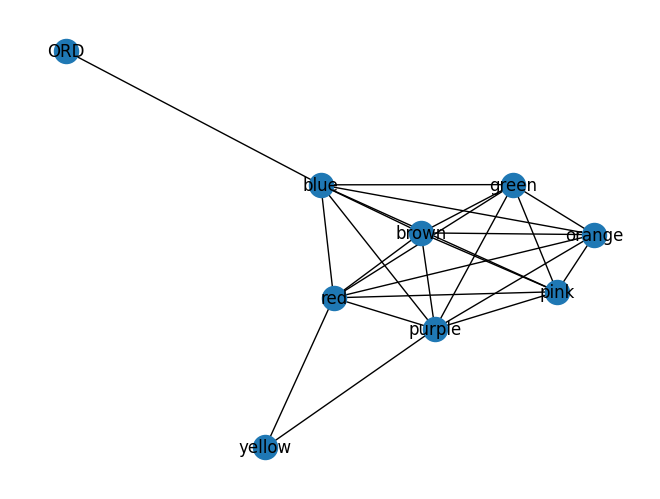

In [18]:
nx.draw(l_lines_graph, with_labels=True)

## CTA Buses

In [19]:
# bus data
cta_bus_routes = gpd.read_file("data/chi/CTA_Bus_Routes_20260506.zip").to_crs(CRS)

In [20]:
bus_routes_graph = nx.Graph()
bus_routes_graph.add_nodes_from(cta_bus_routes["route"])

In [21]:
cta_bus_stops = gpd.read_file("data/chi/CTA_BusStops_20260528.zip")
cta_bus_stops["routes"] = cta_bus_stops["routesstpg"].str.split(",")
cta_bus_stops = cta_bus_stops[cta_bus_stops["routes"].notna()].to_crs(CRS)

In [22]:
# identify the closest node on the street network
bus_stop_nodes, bus_dist_to_closest = ox.nearest_nodes(
    chi_osmnx_data["walk"],
    cta_bus_stops.geometry.x, cta_bus_stops.geometry.y,
    return_dist=True,
)
cta_bus_stops = cta_bus_stops.assign(
    closest_node=bus_stop_nodes,
    dist_to_closest_node=bus_dist_to_closest,
)

In [24]:
bus_stop_coords = {
    row.public_nam: (row.geometry.y, row.geometry.x)
    for _, row in cta_bus_stops.iterrows()
}

bus_stops_dict  = {}   # public_nam  -> [route, ...]
bus_routes_dict = {}   # route       -> [public_nam, ...]

for _, stop in cta_bus_stops.iterrows():
    bus_stops_dict[stop.public_nam] = bus_stops_dict.get(stop.public_nam, []) + stop.routes
    for route in stop.routes:
        bus_routes_dict[route] = bus_routes_dict.get(route, []) + [stop.public_nam]
    for pair in combinations(stop.routes, r=2):
        bus_routes_graph.add_edge(*pair)

bus_stops_dict = {k: list(set(v)) for k, v in bus_stops_dict.items()}

nx.set_node_attributes(bus_routes_graph, bus_routes_dict, name="stops")

bus_stop_to_node_dict = cta_bus_stops.set_index("public_nam")["closest_node"].to_dict()
node_to_bus_stop_dict = cta_bus_stops.set_index("closest_node")["public_nam"].to_dict()
nx.set_node_attributes(chi_osmnx_data["walk"], node_to_bus_stop_dict, name="bus_stop_name")

In [25]:
cta_bus_stops.head()

,systemstop,street,cross_st,dir,pos,routesstpg,owlroutes,city,public_nam,geometry,routes,closest_node,dist_to_closest_node
0,15189.0,CICERO,BERTEAU (north leg),SB,FS,"54,54A",NaN,CHICAGO,Cicero & Berteau,POINT (-87.74751 41.95689),"[54, 54A]",2185494689,7.751686
1,14545.0,HALSTED,119TH STREET,NB,FS,"8A,108",NaN,CHICAGO,Halsted & 119th Street,POINT (-87.64179 41.67799),"[8A, 108]",4332986840,20.175176
2,15046.0,KEDZIE,TOUHY,NB,FS,11,NaN,CHICAGO,Kedzie & Touhy,POINT (-87.70897 42.01205),[11],9952999184,0.644070
3,6280.0,ASHLAND,IRVING PARK,NB,NS,"9,X9",NaN,CHICAGO,Ashland & Irving Park,POINT (-87.66892 41.95419),"[9, X9]",10005669815,2.542734
4,4484.0,ARCHER,DAMEN,SWB,NS,62,N62,CHICAGO,Archer & Damen,POINT (-87.67518 41.83201),[62],10091627212,2.912963


## Metra Trains

In [28]:
#https://www.google.com/maps/d/u/0/viewer?mid=1DgjdcmNOBkOb2sNkZniUMfchyWrjuu0&ll=42.00505398907377%2C-88.08259&z=9

with open("data/chi/Metra Stations by Fare Zone (Since 2024).kml", 'r', encoding="utf-8") as f:
    root = parser.parse(f).getroot()

stations = []
for folder in root.Document.Folder:
    zone_name = folder.name.text
    for placemark in folder.Placemark:
        coords_raw = placemark.Point.coordinates.text.strip()
        lon, lat, _ = coords_raw.split(",")
        stations.append({
            "name": placemark.name.text,
            "zone": zone_name,
            "lat": float(lat),
            "lon": float(lon),
        })

metra_stations_raw = pd.DataFrame(stations)
print(metra_stations_raw)

                         name    zone        lat        lon
0               Union Station  Zone 1  41.879286 -87.638976
1            Van Buren Street  Zone 1  41.877113 -87.623017
2          Millennium Station  Zone 1  41.883670 -87.623205
3    Museum Campus / 11th St.  Zone 1  41.868458 -87.621541
4              LaSalle Street  Zone 1  41.876237 -87.632204
..                        ...     ...        ...        ...
236              Libertyville  Zone 4  42.291047 -87.956216
237             Fort Sheridan  Zone 4  42.217394 -87.821115
238                 New Lenox  Zone 4  41.514536 -87.965225
239                    Aurora  Zone 4  41.759471 -88.309103
240                    Elburn  Zone 4  41.890746 -88.464135

[241 rows x 4 columns]


In [29]:
metra_stations_raw["geometry"] = metra_stations_raw.apply(
    lambda r: Point(r["lon"], r["lat"]), axis=1
)
metra_stations_raw = gpd.GeoDataFrame(metra_stations_raw, geometry="geometry", crs=CRS)


In [30]:
metra_shapefile = gpd.read_file("data/chi/Metra_Stations.zip")


In [ ]:
sjoin_distance      = 0.007
jaro_score_cutoff   = 0.85

joined = metra_shapefile.to_crs(CRS).sjoin(
    metra_stations_raw, distance=sjoin_distance, predicate="dwithin"
)
joined = joined[["LONGNAME", "name", "STATION_ID", "LINES", "zone", "lat", "lon"]]
joined["jaro_score"] = joined.apply(
    lambda r: jaro_similarity(r["LONGNAME"], r["name"]), axis=1
)


In [ ]:
joined[joined["jaro_score"] > jaro_score_cutoff].sort_values("LONGNAME").to_csv("check_metra_names.csv")

In [32]:
metra_line_zones = gpd.read_file("matched_metra_stations.csv")
metra_line_zones["geometry"] = metra_line_zones.apply(
    lambda r: Point(float(r["lon"]), float(r["lat"])), axis=1
)
metra_line_zones = (
    metra_line_zones
    .set_geometry("geometry", crs=CRS)
    [["STATION_ID", "name", "LINES", "zone", "geometry"]]
    .rename(columns={"LINES": "line"})
    .set_index("STATION_ID")
)

In [ ]:
# identify the closest node on the street network
metra_stop_nodes, metra_dist_to_closest = ox.nearest_nodes(
    chi_osmnx_data["walk"],
    metra_line_zones.geometry.x, metra_line_zones.geometry.y,
    return_dist=True,
)
metra_line_zones = metra_line_zones.assign(
    closest_node=metra_stop_nodes,
    dist_to_closest_node=metra_dist_to_closest,
)
# Null out nodes that are too far away to be reliable snaps
metra_line_zones.loc[metra_line_zones["dist_to_closest_node"] >= 100, "closest_node"]        = None
metra_line_zones.loc[metra_line_zones["dist_to_closest_node"] >= 100, "dist_to_closest_node"] = None

metra_line_zones["lines"] = metra_line_zones["line"].str.split(", ")

In [548]:
LINE_COLS = ["Rock Is.", "Electric", "SWS", "S. Shore", "NCS", 
             "UP-NW", "BNSF", "Milw-W", "UP-W", "UP-N", "Milw-N", "Heritage"]


for line in LINE_COLS:
    metra_line_zones[line] = metra_line_zones["lines"].apply(
        lambda l: line in l
    )

In [545]:
metra_stop_coords = {
    row["name"]: (row["geometry"].y, row["geometry"].x)
    for _, row in metra_line_zones.iterrows()
}

In [417]:
metra_station_to_node_dict = metra_line_zones.dropna().set_index("name")["closest_node"].to_dict()
node_to_metra_station_dict = metra_line_zones.dropna().set_index("closest_node")["name"].to_dict()

nx.set_node_attributes(city_data[CHI]["walk"], node_to_l_station_dict, name="metra_station_name")

In [416]:
nx.get_node_attributes(city_data[CHI]["walk"], "metra_station_name")

{256633656: 'Racine (Blue Line)',
 261096312: '47th (Red Line)',
 261103882: 'Rosemont (Blue Line)',
 261153227: 'Forest Park (Blue Line)',
 261195515: 'Austin (Blue Line)',
 262184215: 'Quincy/Wells (Brown, Orange, Purple & Pink lines)',
 1607674896: "Harlem (Blue Line - O'Hare Branch)",
 1885912488: 'Western (Blue Line - Forest Park Branch)',
 2090233637: 'Illinois Medical District (Blue Line)',
 2114873916: 'Dempster-Skokie  (Yellow Line)',
 2178993580: 'Kimball (Brown Line)',
 2400637259: 'Rockwell (Brown Line)',
 2437252824: 'Kostner (Pink Line)',
 2565193689: 'Harrison (Red Line)',
 2610485485: 'Chicago (Blue Line)',
 2883955136: 'Jefferson Park (Blue Line)',
 2884007590: 'Montrose (Blue Line)',
 3656037624: 'Damen (Blue Line)',
 4606976494: '35th-Bronzeville-IIT (Green Line)',
 5678317832: 'Merchandise Mart (Brown & Purple lines)',
 5839695422: 'King Drive (Green Line)',
 6044544590: 'Sox-35th (Red Line)',
 6369524392: 'Irving Park (Blue Line)',
 6375121291: 'Cicero (Green Line)

<Axes: >

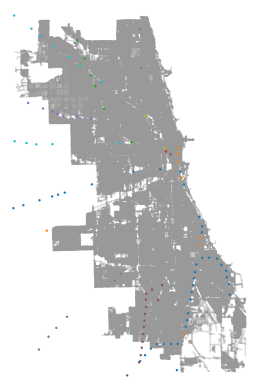

In [388]:
fig, ax = plt.subplots()
plot_base_graph(city_data[CHI]["walk"], ax=ax)
metra_line_zones.plot(ax=ax, column="line", markersize=1)

In [472]:
metra_fares = pd.read_csv("data/chi/metra_zone_fares.csv")
metra_fares

,source,target,fare
0,Zone 1,Zone 2,3.75
1,Zone 1,Zone 3,5.50
2,Zone 1,Zone 4,6.75
3,Zone 2,Zone 3,3.75
4,Zone 2,Zone 4,3.75
5,Zone 3,Zone 4,3.75
6,Zone 1,Zone 1,3.75
7,Zone 2,Zone 2,3.75
8,Zone 3,Zone 3,3.75
9,Zone 4,Zone 4,3.75


In [473]:
metra_fare_graph = nx.from_pandas_edgelist(metra_fares, edge_attr=True)

EdgeView([('Zone 1', 'Zone 2'), ('Zone 1', 'Zone 3'), ('Zone 1', 'Zone 4'), ('Zone 1', 'Zone 1'), ('Zone 2', 'Zone 3'), ('Zone 2', 'Zone 4'), ('Zone 2', 'Zone 2'), ('Zone 3', 'Zone 4'), ('Zone 3', 'Zone 3'), ('Zone 4', 'Zone 4')])

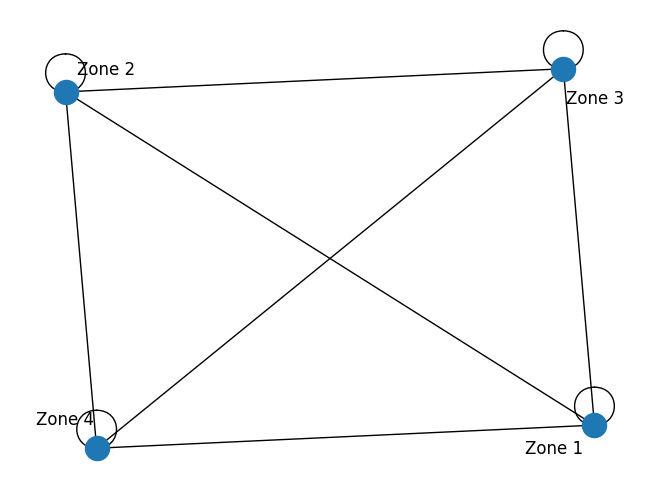

In [493]:
nx.draw(metra_fare_graph)
nx.draw_networkx_labels(metra_fare_graph, pos=nx.spring_layout(metra_fare_graph))
metra_fare_graph.edges

## Bikeshare: Divvy

In [108]:
# read in
divvy_stations = gpd.read_file("data/chi/Divvy Bicycle Stations_20260520.zip")
divvy_stations = divvy_stations.to_crs(CRS)

In [229]:
# identify the closest node on the street network
chi_divvy_nodes, dist_to_closest_node = ox.nearest_nodes(
    city_data[CHI]["walk"], divvy_stations.geometry.x, divvy_stations.geometry.y,
    return_dist=True
)
divvy_stations = divvy_stations.assign(closest_node=chi_divvy_nodes, dist_to_closest_node=dist_to_closest_node)
divvy_stations.head()

,id,station_na,short_name,total_dock,docks_in_s,status,latitude,longitude,geometry,closest_node,dist_to_closest_node
0,1859717767703464460,Kedzie Ave & Redfield Dr,CHI01795,15.0,15.0,In Service,41.765230,-87.703160,POINT (-87.70316 41.76523),2373184965,12.701778
1,a3a95142-a135-11e9-9cda-0a87ae2ba916,Lincoln Ave & Waveland Ave,CHI00446,15.0,15.0,In Service,41.948797,-87.675278,POINT (-87.67528 41.9488),10187562047,9.128591
2,1890602768178733256,Leclaire Ave & Belmont Ave,CHI01764,15.0,15.0,In Service,41.939041,-87.754197,POINT (-87.7542 41.93904),4957753257,17.332150
3,a3a6f2a2-a135-11e9-9cda-0a87ae2ba916,Damen Ave & Clybourn Ave,CHI00348,15.0,15.0,In Service,41.932210,-87.678590,POINT (-87.67859 41.93221),13547448853,14.535697
4,1936560699993133354,Artesian Ave & 55th St,CHI01923,15.0,15.0,In Service,41.794020,-87.685770,POINT (-87.68577 41.79402),13271333274,8.825646


In [ ]:
divvy_station_to_node_dict = divvy_stations.set_index("station_na")["closest_node"].to_dict()
node_to_divvy_station_dict = divvy_stations.set_index("closest_node")["station_na"].to_dict()
nx.set_node_attributes(city_data[CHI]["walk"], node_to_divvy_station_dict, name="divvy_station_name")

In [147]:
def divvy_cost_function(time_s):
    return 1 + (0.20 * (time_s / 60))

my_cost_function = divvy_cost_function

In [ ]:
### hide
import networkx.algorithms.shortest_paths.weighted as nx_weighted
from heapq import heappop, heappush
from itertools import count, islice

#https://networkx.org/documentation/stable/_modules/networkx/algorithms/shortest_paths/weighted.html#multi_source_dijkstra


def my_dijkstra_multisource(
    G, sources, weight, pred=None, paths=None, cutoff=None, target=None
):
    """Uses Dijkstra's algorithm to find shortest weighted paths

    Parameters
    ----------
    G : NetworkX graph

    sources : non-empty iterable of nodes
        Starting nodes for paths. If this is just an iterable containing
        a single node, then all paths computed by this function will
        start from that node. If there are two or more nodes in this
        iterable, the computed paths may begin from any one of the start
        nodes.

    weight: function
        Function with (u, v, data) input that returns that edge's weight
        or None to indicate a hidden edge

    pred: dict of lists, optional(default=None)
        dict to store a list of predecessors keyed by that node
        If None, predecessors are not stored.

    paths: dict, optional (default=None)
        dict to store the path list from source to each node, keyed by node.
        If None, paths are not stored.

    target : node label, optional
        Ending node for path. Search is halted when target is found.

    cutoff : integer or float, optional
        Length (sum of edge weights) at which the search is stopped.
        If cutoff is provided, only return paths with summed weight <= cutoff.

    Returns
    -------
    distance : dictionary
        A mapping from node to shortest distance to that node from one
        of the source nodes.

    Raises
    ------
    NodeNotFound
        If any of `sources` is not in `G`.

    Notes
    -----
    The optional predecessor and path dictionaries can be accessed by
    the caller through the original pred and paths objects passed
    as arguments. No need to explicitly return pred or paths.

    """
    # If `paths` is specified, we use a temporary internal dictionary (`pred_dict`) to
    # store predecessors, used to reconstruct paths. However, if the caller
    # passed in a `pred` dictionary, we must compute *all* predecessors, since the caller
    # expects the full predecessor structure.
    pred_dict = pred if paths is None or pred is not None else {}

    G_succ = G._adj  # For speed-up (and works for both directed and undirected graphs)

    dist = {}  # dictionary of final distances
    seen = {}
    # fringe is heapq with 3-tuples (distance,c,node)
    # use the count c to avoid comparing nodes (may not be able to)
    c = count()
    fringe = []
    for source in sources:
        seen[source] = 0
        heappush(fringe, (0, next(c), source))
    number_of_sources = len(seen)
    while fringe:
        (dist_v, _, v) = heappop(fringe)
        if v in dist:
            continue  # already searched this node.
        dist[v] = dist_v
        if v == target:
            break
        for u, e in G_succ[v].items():
            cost = weight(v, u, e)
            if cost is None:
                continue
            vu_dist = dist_v + cost
            if cutoff is not None and my_cost_function(vu_dist) > cutoff:
                #print(f"cost function: {my_cost_function(vu_dist)}, cutoff: {cutoff}"")
                continue
            if u in dist:
                u_dist = dist[u]
                if vu_dist < u_dist:
                    raise ValueError("Contradictory paths found:", "negative weights?")
                elif pred is not None and vu_dist == u_dist:
                    # Found another shortest path to u with equal distance (including zero-weight edges).
                    # We must store *all* predecessors because `pred` was provided by the caller.
                    pred_dict[u].append(v)
            elif u not in seen or vu_dist < seen[u]:
                seen[u] = vu_dist
                heappush(fringe, (vu_dist, next(c), u))
                if pred_dict is not None:
                    pred_dict[u] = [v]
            elif pred is not None and vu_dist == seen[u]:
                # Found another shortest path to u
                # We must store *all* predecessors because `pred` was provided by the caller.
                pred_dict[u].append(v)

    if paths is not None:
        # Reconstruct the path from source to target using the predecessor dictionary.
        if target is None:
            # Since `dist` is in increasing distance order, each predecessor's path is
            # already computed by the time we process `v`. We skip the first
            # `number_of_sources` entries because sources already have their paths defined.
            for v in islice(dist, number_of_sources, None):
                # `v` must be in `pred_dict`: any node with a distance (and not a source)
                # has a predecessor.
                paths[v] = paths[pred_dict[v][0]] + [v]
        else:
            # Caller requested the path to a specific target node.
            path = paths[target] = [target]
            while (current_preds := pred_dict.get(path[-1])) is not None:
                path.append(current_preds[0])
            # The path was built in reverse order, so reverse it at the end.
            path.reverse()

    # The optional predecessor and path dictionaries can be accessed
    # by the caller via the pred and paths objects passed as arguments.
    return dist


nx_weighted._dijkstra_multisource = my_dijkstra_multisource

In [ ]:
# @markdown This cell defines `make_convex_hull_isochrones`, which builds
# @markdown convex-hull isochrone polygons from a graph and a set of starting nodes.
# @markdown We'll use it for walking below, and again for biking and driving.


def make_convex_hull_isochrones(graph, node_array, fare_costs):
    isochrone_polys = {t: [] for t in fare_costs}
    for node in tqdm(node_array):
        for cost in sorted(fare_costs, reverse=True):
            egograph = nx.ego_graph(graph, node, radius=cost, distance="time_s")
            subgraph = egograph.subgraph(chi_divvy_nodes)
            node_points = [
                Point((data["x"], data["y"])) for _, data in subgraph.nodes(data=True)
            ]
            isochrone_polys[cost].append(
                gpd.GeoSeries(node_points).union_all().convex_hull
            )
    return isochrone_polys

In [171]:
isochrone_polys = make_convex_hull_isochrones(city_data[CHI]["bike"], [1536820572], [0.5, 2, 5])

  0%|          | 0/1 [00:00<?, ?it/s]

5.062590507166086 5
5.042491724089076 5
5.506983302983136 5
5.5382112161120425 5
5.101935597231007 5
5.0129641719227775 5
5.202055434356079 5
5.023294933224374 5
5.056310699231211 5
5.013117801395752 5
5.218126619441331 5
5.0076458541845685 5
5.0119800341208816 5
5.01735800446258 5
5.037037753224965 5
5.078497361547789 5
5.917416008203911 5
5.091441429800169 5
5.142014491864831 5
5.044619030657855 5
5.0148189839096755 5
5.071193720547831 5
5.042884422066092 5
5.0012705121430585 5
5.077390269786797 5
5.002154246468616 5
5.001713057256743 5
5.020360762951571 5
5.0017404001836345 5
5.012633352548076 5
5.013198648874318 5
5.010652504405836 5
5.051752359645422 5
5.01194514579059 5
5.010669134188947 5
5.019884670226522 5
5.015353740284051 5
5.005008391401769 5
5.0192029242742935 5
5.098169010567624 5
5.043135079922907 5
5.020871467216915 5
5.074202769671465 5
5.021631668578255 5
5.023842865719282 5
5.026044456641797 5
5.063532943145059 5
5.005407794838578 5
5.025544200158545 5
5.005495344803

100%|██████████| 1/1 [00:00<00:00,  1.57it/s]

2.001844388367619 2
2.014843095493095 2
2.006534435502447 2
2.0141008272812413 2
2.011167448731417 2
2.015659721779471 2
2.0179997851008604 2
2.0198069449444667 2
2.019724599777584 2
2.0162161353120824 2
2.080529714749833 2
2.0255443935200326 2
2.006554895134969 2
2.0446517575147753 2
2.050582852752428 2
2.0518085860834256 2
2.0147277890575985 2
2.054196872673853 2
2.0168299671157968 2
2.0173669311368148 2
2.0194037955069577 2
2.0182804285015945 2
2.019674143578059 2
2.01846478106303 2
2.059789778167317 2
2.054136568193929 2
2.058785723012943 2
2.0146774964092105 2
2.019117136044011 2
2.0210998954765813 2
2.0217708709475803 2
2.0249642811966746 2
2.061384380443467 2
2.0581658413525057 2
2.0605400123440214 2
2.0142101830005634 2
2.0267288500735656 2
2.0182744398423136 2
2.0684782226196026 2
2.069061048597204 2
2.070716561012906 2
2.034708389673531 2
2.0755012556191534 2
2.036733784926617 2
2.0373650945461685 2
2.0310975324651928 2
2.0167341645166306 2
2.074936481791969 2
2.0362827457199

In [168]:
# A helper function to convert the isochrone polygons into a geodataframe
def polys_to_gdf(isochrone_polys, fare_costs, crs=CRS):
    gdf_list = []
    for cost in fare_costs:
        gdf = gpd.GeoDataFrame(geometry=isochrone_polys[cost], crs=crs)
        gdf["cost"] = cost
        gdf_list.append(gdf)

    output_gdf = pd.concat(gdf_list, ignore_index=True)
    return output_gdf

In [172]:
isochrone_gdf = polys_to_gdf(isochrone_polys, [0.50, 2, 5])
isochrone_gdf

,geometry,cost
0,POINT (-87.67547 41.94874),0.5
1,"POLYGON ((-87.67838 41.94049, -87.6834 41.9468...",2.0
2,"POLYGON ((-87.66268 41.90534, -87.67735 41.906...",5.0


In [191]:
# @markdown This cell contains helper functions for plotting our isochrones
# @markdown and street network together. Namely `plot_base_graph` which plots
# @markdown the street network with consistent styling, and `make_color_legend`
# @markdown which creates a legend with square boxes for our isochrone colors.
def make_color_legend(ax, colors, labels):
    lines = [
        mlines.Line2D(
            [0], [0], linestyle="none", marker="s",
            markersize=10, markerfacecolor=color
        )
        for color in colors
    ]
    ax.legend(lines, labels)


def plot_base_graph(graph, ax=None):
    return ox.plot_graph(
        graph,
        ax=ax,
        show=False,
        close=False,
        edge_color="#999999",
        edge_alpha=0.2,
        node_size=0,
        bgcolor="w",
    )

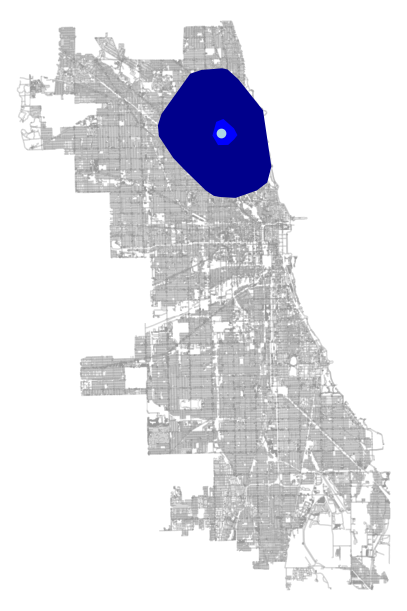

In [192]:
fig, ax = plt.subplots(figsize=[5, 10])

plot_base_graph(city_data[CHI]["bike"], ax=ax)

for i, (cost, color) in enumerate(zip(reversed([0.50, 2, 5]), ["darkblue", "blue", "lightblue"])):
    isochrone_gdf[isochrone_gdf["cost"] == cost].plot(ax=ax, color=color)


<Axes: >

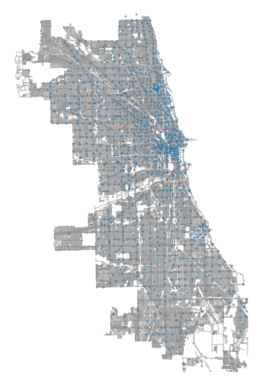

In [194]:
fig, ax = plt.subplots()

plot_base_graph(city_data[CHI]["bike"], ax=ax)

divvy_stations.plot(ax=ax, markersize=0.1)

Putting it together

In [402]:
def nodes_within_walk(city, origin):
    walk_graph = city_data[city]["walk"]
    starting_point = ox.nearest_nodes(walk_graph, origin.x, origin.y)
    subgraph = nx.ego_graph(walk_graph, starting_point, radius=WALK_RADIUS_M, distance="length")
    return [(node, Point(data["x"], data["y"])) for node, data in subgraph.nodes(data=True)]

def stops_within_walk(city, origin, transit_stop_nodes):
    """
    Return transit stop nodes within WALK_RADIUS_M of origin.
    """
    return [(node, pt) for node, pt in nodes_within_walk(city, origin) if node in transit_stop_nodes]



In [400]:
origin = Point(-87.68513, 41.85422)
n = nodes_within_walk(CHI, origin)

In [ ]:
# testing block
origin = Point(-87.68513, 41.85422)
transit_stop_nodes = [11762122793, 2073720876, 9910104111, 9910004111]
stops_within_walk(CHI, origin, transit_stop_nodes)

{2073720876, 9910104111, 11762122793}

In [ ]:
def get_reachable_metra(station_name, budget):
    station_details = metra_line_zones[metra_line_zones["name"] == station_name].to_dict("records")[0]
    station_lines = station_details["lines"]
    zone = station_details["zone"]
    reachable = {} 
    for line in station_lines:
        fare_mat = metra_line_zones[metra_line_zones[line]].copy()
        fare_mat["fare"] = fare_mat["zone"].apply(
            lambda z: metra_fare_graph[zone].get(z, {}).get("fare", None)
        )
        reachable_on_line = (
            fare_mat[fare_mat["fare"] <= budget][["name", "geom", "closest_node"]]
            .set_index("name")
            .to_dict("index")
        )
        reachable.update(reachable_on_line)

    return reachable 

def get_reachable_cta_bus(stop_id, budget):
    stop_lines = set(bus_stops_dict[stop_id])
    reachable_lines = nx.Graph()
    reachable_stops = []
    if budget < 2.25:
        reachable_nodes = bus_stop_to_node_dict[stop_id]
    elif budget >= 2.25:
        for line in stop_lines:
            reachable_lines = nx.compose(reachable_lines, nx.ego_graph(bus_routes_graph, line, radius=2))
            # get nodes of reachable stops (all stops)
        for line in reachable_lines.nodes:
            reachable_stops = reachable_stops + bus_routes_dict[line]
            reachable_nodes = [bus_stop_to_node_dict[stop] for stop in reachable_stops]

    return reachable_nodes

def get_reachable_cta_l(stop_id, budget):
    stop_lines = l_station_to_lines_dict[stop_id]

    if budget < 2.50 or (budget < 5 and "blue" in stop_lines
                         and l_stations[l_stations["stop_id"] == stop_id].iloc[0]["station_name"] == "O'Hare"):
        reachable_stops = [stop_id]
    else:
        reachable_lines = nx.Graph()
        for line in stop_lines:
            reachable_lines = nx.compose(reachable_lines,
                                         nx.ego_graph(l_lines_graph, line, radius=2))
        reachable_stops = []
        for line in reachable_lines.nodes:
            reachable_stops += l_lines_to_stations_dict[line]
        reachable_stops = list(set(reachable_stops))

    return [l_stop_coords[s] for s in reachable_stops if s in l_stop_coords]

def get_reachable_divvy(station_name, budget):
    node = divvy_station_to_node_dict[station_name]
    egograph = nx.ego_graph(city_data[CHI]["bike"], node, radius=budget, distance="time_s")
    reachable_nodes = list(egograph.nodes())
    return reachable_nodes


In [528]:
from math import radians, cos, sin, asin, sqrt

def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in metres between two (lat, lon) points."""
    R = 6_371_000
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlam = radians(lon2 - lon1)
    a = sin(dphi / 2) ** 2 + cos(phi1) * cos(phi2) * sin(dlam / 2) ** 2
    return 2 * R * asin(sqrt(a))

In [522]:
def stops_within_walk(origin_lat, origin_lon, stops_df):
    stops_df = stops_df.copy()
    
    # Handle both geometry and lat/lon columns
    if "geometry" in stops_df.columns:
        stops_df["_lat"] = stops_df.geometry.y
        stops_df["_lon"] = stops_df.geometry.x
    else:
        stops_df["_lat"] = stops_df["lat"]
        stops_df["_lon"] = stops_df["lon"]
    
    stops_df["_dist_m"] = stops_df.apply(
        lambda r: haversine(origin_lat, origin_lon, r._lat, r._lon), axis=1
    )
    return stops_df[stops_df["_dist_m"] <= WALK_RADIUS_M].copy()

In [558]:
def get_reachable_metra(station_name, budget):
    station = metra_line_zones[metra_line_zones["name"] == station_name].iloc[0]
    zone = station["zone"]
    station_lines = [l for l in LINE_COLS if station[l]]

    reachable = {}
    for line in station_lines:
        fare_mat = metra_line_zones[metra_line_zones[line]].copy()
        fare_mat["fare"] = fare_mat["zone"].apply(
            lambda z: metra_fare_graph[zone].get(z, {}).get("fare", None)
        )
        reachable_on_line = fare_mat[fare_mat["fare"] <= budget]["name"].tolist()
        for name in reachable_on_line:
            reachable[name] = metra_stop_coords[name]

    return list(reachable.values())


def get_reachable_cta_bus(stop_id, budget):
    """stop_id is public_nam, e.g. 'Cicero & Berteau'"""
    if budget < 2.25:
        reachable_stops = [stop_id]
    else:
        stop_lines = set(bus_stops_dict[stop_id])
        reachable_lines = nx.Graph()
        for line in stop_lines:
            reachable_lines = nx.compose(reachable_lines, nx.ego_graph(bus_routes_graph, line, radius=2))
        reachable_stops = []
        for line in reachable_lines.nodes:
            reachable_stops += bus_routes_dict[line]
        reachable_stops = list(set(reachable_stops))
    return [bus_stop_coords[s] for s in reachable_stops if s in bus_stop_coords]


def get_reachable_cta_l(stop_id, budget):
    """stop_id is station_descriptive_name, e.g. '18th (Pink Line)'"""
    stop_lines = l_station_to_lines_dict[stop_id]

    if budget < 2.50 or (budget < 5 and "O'Hare (Blue Line)" in stop_id):
        reachable_stops = [stop_id]
    else:
        reachable_lines = nx.Graph()
        for line in stop_lines:
            reachable_lines = nx.compose(reachable_lines,
                                         nx.ego_graph(l_lines_graph, line, radius=2))
        reachable_stops = []
        for line in reachable_lines.nodes:
            reachable_stops += l_lines_to_stations_dict[line]
        reachable_stops = list(set(reachable_stops))

    return [l_stop_coords[s] for s in reachable_stops if s in l_stop_coords]


def get_reachable_divvy(station_name, budget):
    node = divvy_station_to_node_dict[station_name]
    egograph = nx.ego_graph(city_data[CHI]["bike"], node, radius=budget, distance="time_s")
    reachable_nodes = list(egograph.nodes())
    return [(city_data[CHI]["bike"].nodes[n]["y"], city_data[CHI]["bike"].nodes[n]["x"])
            for n in reachable_nodes]


def get_reachable_all_modes(origin_lat, origin_lon, budget,
                             metra_stations, cta_bus_stops, cta_l_stops, divvy_stations):
    all_coords = []

    for stops_df, reach_fn, id_col in [
        (metra_stations,  get_reachable_metra,   "name"),
        (cta_bus_stops,   get_reachable_cta_bus, "stop_id"),
        (cta_l_stops,     get_reachable_cta_l,   "stop_id"),
        (divvy_stations,  get_reachable_divvy,   "name"),
    ]:
        nearby = stops_within_walk(origin_lat, origin_lon, stops_df)
        for _, row in nearby.iterrows():
            all_coords.extend(reach_fn(row[id_col], budget))

    return list(set(all_coords))

In [568]:
get_reachable_cta_bus("Kedzie & 48th Place", 5)

[(41.740250823, -87.604794642),
 (41.77867563299998, -87.74214677600003),
 (41.99812067800002, -87.65844625300002),
 (41.794863256999975, -87.60735134800001),
 (41.877590708000014, -87.68868466700002),
 (41.749172999999985, -87.734334999),
 (41.86563456800002, -87.627553364),
 (41.939305515, -87.71487204499999),
 (41.889482000999976, -87.68658299999998),
 (41.99016326200001, -87.71388950400001),
 (41.876689999999996, -87.62416000000002),
 (41.89543434199999, -87.70646001199998),
 (41.80131723699998, -87.66953420099998),
 (41.916945999999996, -87.740095),
 (41.793687503, -87.65935061200003),
 (41.80935510500001, -87.591645202),
 (41.942914367000014, -87.698011672),
 (41.779122755, -87.69818543999997),
 (41.92381729700003, -87.78055022500001),
 (41.877395190000016, -87.70627811499998),
 (41.81957523199998, -87.69463137600002),
 (41.77933100000001, -87.66673899900002),
 (41.84440238399998, -87.71743828400002),
 (41.73394601000001, -87.55126926100002),
 (41.80091524599999, -87.703866061999

In [550]:
get_reachable_metra("University Park", 10)

[(41.706983, -87.607304),
 (41.699607, -87.608997),
 (41.692722, -87.610574),
 (41.622699, -87.635967),
 (41.857918, -87.618033),
 (41.50631, -87.698144),
 (41.844244, -87.613467),
 (41.809541, -87.591262),
 (41.799711, -87.587009),
 (41.793272, -87.587641),
 (41.787652, -87.588946),
 (41.779863, -87.590699),
 (41.758978, -87.595437),
 (41.750852, -87.597284),
 (41.74538, -87.551571),
 (41.744226, -87.598793),
 (41.738188, -87.548295),
 (41.736968, -87.600446),
 (41.729736, -87.602097),
 (41.726963, -87.547785),
 (41.721763, -87.603938),
 (41.669389, -87.660639),
 (41.656006, -87.675906),
 (41.766154, -87.577146),
 (41.66234, -87.668805),
 (41.572888, -87.662665),
 (41.752153, -87.55267),
 (41.543366, -87.67841),
 (41.608434, -87.64369),
 (41.580828, -87.658429),
 (41.562689, -87.668146),
 (41.633671, -87.63014),
 (41.685719, -87.612147),
 (41.498553, -87.702339),
 (41.851392, -87.616227),
 (41.88367, -87.623205),
 (41.868458, -87.621541),
 (41.521168, -87.690235),
 (41.6741, -87.65196

In [525]:
get_reachable_divvy("Clark St & Montrose Ave", 3)

3.1767720272377216 3
3.2600641780963295 3
3.1242194479232475 3
3.1671668565819493 3
3.0467659828316687 3
3.0331514425547716 3
3.0013270524937297 3
3.0759383711027795 3
3.1503348150301225 3
3.1488644339369354 3
3.3690971610467577 3
3.0328398202800293 3
3.0064101647752515 3
3.0044135606820364 3
3.023762384569918 3
3.0012172289292818 3
3.0020866963719928 3
3.002380046180814 3
3.0098381476980194 3
3.0060547532589914 3
3.0324809965859667 3
3.0452640297071936 3
3.0319817825152113 3
3.0175278548565987 3
3.031942328599562 3
3.020599008976992 3
3.016560047677586 3
3.003013327116152 3
3.0233819527891934 3
3.026574951699384 3
3.019561937473679 3
3.026172032305377 3
3.030772447426608 3
3.0281424243417203 3
3.0709522918195877 3
3.0278262494259223 3
3.032831466078704 3
3.038177500820221 3
3.038833530175744 3
3.0387899833430754 3
3.0912359349879046 3
3.0042170354675384 3
3.111679067846259 3
3.0424114872827963 3
3.042306590393751 3
3.1348904897294196 3
3.0363334328574827 3
3.0030107097000567 3
3.01029

[(41.9530714, -87.6550524),
 (41.971177, -87.6720978),
 (41.9711782, -87.6718802),
 (41.9799892, -87.6592069),
 (41.9403049, -87.6559424),
 (41.940313, -87.6553303),
 (41.9667306, -87.6456307),
 (41.9548514, -87.6875316),
 (41.9681414, -87.6734599),
 (41.9681336, -87.6741488),
 (41.9667386, -87.6443051),
 (41.9799953, -87.658613),
 (41.9536254, -87.6520983),
 (41.9429714, -87.6578342),
 (41.9429624, -87.6584441),
 (41.9426121, -87.6590497),
 (41.9849597, -87.6684945),
 (41.9421171, -87.6593402),
 (41.9799687, -87.6606395),
 (41.9817384, -87.6643128),
 (41.9668948, -87.6456712),
 (41.9544453, -87.6884775),
 (41.9672176, -87.6457517),
 (41.9589506, -87.6562668),
 (41.9456699, -87.6683274),
 (41.9456595, -87.6687625),
 (41.9466718, -87.6687896),
 (41.9466758, -87.6682449),
 (41.9817572, -87.6630989),
 (41.9762558, -87.6641517),
 (41.9668943, -87.6443464),
 (41.9633103, -87.6768593),
 (41.9607772, -87.6556048),
 (41.9607805, -87.65542),
 (41.9609194, -87.655429),
 (41.9609167, -87.6556083)

In [559]:
get_reachable_cta_l("O'Hare (Blue Line)", 6)

[(41.874257, -87.817318),
 (41.831677, -87.625826),
 (41.878153, -87.627596),
 (41.891665, -87.628021),
 (41.853115, -87.626402),
 (41.8768, -87.631739),
 (41.878183, -87.629296),
 (41.916157, -87.687364),
 (41.887293, -87.774135),
 (41.799756, -87.724493),
 (41.882695, -87.63378),
 (42.04771, -87.683543),
 (41.88497405, -87.67689149),
 (41.768367, -87.625724),
 (41.870851, -87.776812),
 (41.888969, -87.633924),
 (41.853206, -87.630968),
 (41.831191, -87.630636),
 (41.854517, -87.675975),
 (41.804236, -87.704406),
 (41.875539, -87.640984),
 (41.780309, -87.605857),
 (41.875706, -87.673932),
 (41.969139, -87.658493),
 (41.921939, -87.69689),
 (41.87349, -87.806961),
 (41.874039, -87.627479),
 (41.983507, -87.859388),
 (42.02624348, -87.74722084),
 (41.872108, -87.791602),
 (42.058282, -87.683337),
 (41.886848, -87.803176),
 (41.79542, -87.631157),
 (41.853732, -87.724311),
 (42.019063, -87.672892),
 (41.854109, -87.694774),
 (41.896671, -87.628176),
 (41.943744, -87.663619),
 (41.853839

In [526]:
def plot_reachable(origin_lat, origin_lon, coords, zoom=11, tiles="CartoDB Positron"):
    """
    Quick diagnostic plot of reachable coords from get_reachable_all_modes
    (or any individual mode function).
    
    coords: list of (lat, lon) tuples
    """
    m = folium.Map(location=[origin_lat, origin_lon], zoom_start=zoom, tiles=tiles)

    # Origin marker
    folium.CircleMarker(
        location=[origin_lat, origin_lon],
        radius=8, color="#fff", fill=True,
        fill_color="#000", fill_opacity=1, weight=2,
        tooltip="Origin"
    ).add_to(m)

    # Walk radius
    folium.Circle(
        location=[origin_lat, origin_lon],
        radius=WALK_RADIUS_M,
        color="white", fill=False,
        weight=1.5, dash_array="5 5", opacity=0.5,
    ).add_to(m)

    # Reachable points
    for lat, lon in coords:
        folium.CircleMarker(
            location=[lat, lon],
            radius=4, color="#00a1de",
            fill=True, fill_color="#00a1de", fill_opacity=0.7,
            weight=1,
        ).add_to(m)

    # Summary
    folium.map.Marker(
        [origin_lat + 0.002, origin_lon],
        icon=folium.DivIcon(html=f"""
            <div style="font-family:monospace; font-size:12px; font-weight:bold;
                        color:white; background:rgba(0,0,0,0.65);
                        padding:3px 8px; border-radius:4px; white-space:nowrap;">
                {len(coords)} reachable points
            </div>
        """)
    ).add_to(m)

    return m

In [567]:
# Test a single mode
# coords = get_reachable_metra("Union Station", budget=10.00)
# plot_reachable(41.8791, -87.6399, coords)

# Test all modes combined from a click point
coords = get_reachable_all_modes(41.8827, -87.6233, budget=5.00,
                                  metra_stations=metra_stations,
                                  cta_bus_stops=cta_bus_stops,
                                  cta_l_stops=l_stations,
                                  divvy_stations=divvy_stations)
plot_reachable(41.8827, -87.6233, coords)

KeyError: 'stop_id'